Используя знания из практической части урока и функцию blur_face (размытие), проведи следующий эксперимент:

Найди фото любого известного актера или актрисы.

Распознай лицо на фотографии. Выдели лицо овалом. Метод для рисования овала, найди самостоятельно.

Выдели на изображении глаза.
Выдели их кружком.
Если ты чувствуешь в себе суперсилу и дополнительный бекграунд знаний, и хочешь получить больше баллов за задание, то нарисуй вместо кружков солнцезащитные очки (картинку очков можно найти в интернете, задача их правильно масштабировать и разместить).

Все лицо кроме глаз необходимо "заблюрить" (размыть) с помощью функции.
Оценка за задание:

1 балл - задача решена с помощью куратора, лицо распознано прямоугольником, глаза кругом.

2 балла - задача решена с незначительными подсказками куратора, лицо распознано прямоугольником или кругом, глаза кругом, лицо размыто.

3 балла - задача решена самостоятельно, лицо распознано овалом, глаза кругом, удалось заблюрить лицо, не затронув глаза.

4 балла - задача решена самостоятельно на 3 балла, удалось нарисовать очки с подсказкой куратора, недостаточна соблюдена симметрия расположения очков или недостаточно учтены их размеры.

5 баллов - задача полностью решена самостоятельно, все пункты выполнены.

In [ ]:
import cv2
import gdown
from matplotlib import pyplot
# Команда обеспечивает вывод графиков в Google Colaboratory
%matplotlib inline

In [ ]:
gdown.download('https://drive.google.com/drive/my-drive/m1000x1000.jpg', None, quiet=True)


'm1000x1000.jpg'

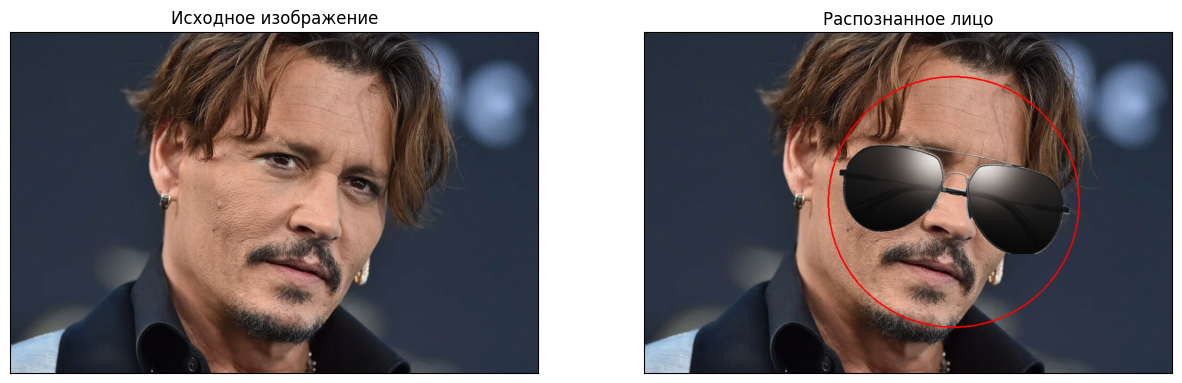

In [ ]:

# Загрузка изображения
img = cv2.imread('/m1000x1000.jpg')

img2 = img.copy() # копирование переменной

# загрузка каскада Хаара
classifier = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_frontalface_default.xml")

# загрузка каскада Хаара для поиска глаз
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_eye.xml")

# выполнение распознавания лиц
bboxes = classifier.detectMultiScale(img)

# загрузка изображения очков
glasses = cv2.imread('/Black-Glasses-PNG-Transparent-Image.png', -1)  # -1 для загрузки с альфа-каналом

# формирование овала вокруг каждого обнаруженного лица
for box in bboxes:
    # формирование координат
    x, y, width, height = box
    # вычисление центра и радиусов для овала
    center = (x + width // 2, y + height // 2)
    axes = (width // 2, height // 2)  # радиусы по осям
    # рисование овала
    cv2.ellipse(img2, center, axes, 0, 0, 360, (0, 0, 255), 2)

    face = img2[y:y + height, x:x + width]  # найденная область с лицом

    # выполнение распознавания глаз с измененными параметрами так как он думает что область под губой это глаз...
    eyes = classifier_eye.detectMultiScale(face, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # вставка очков на лицо
    if len(eyes) > 0:  # если найдены глаза
        # вычисление позиции для наложения очков
        glasses_width = width
        glasses_height = int(glasses.shape[0] * (glasses_width / glasses.shape[1]))
        glasses_resized = cv2.resize(glasses, (glasses_width, glasses_height))

        # определение позиции для наложения
        y_offset = y + int(height / 4)  # немного выше центра лица
        x_offset = x  # по ширине лица

        M = cv2.getRotationMatrix2D((glasses_resized.shape[1] // 2, glasses_resized.shape[0] // 2), -10, 1)
        glasses_rotated = cv2.warpAffine(glasses_resized, M, (glasses_resized.shape[1], glasses_resized.shape[0]))

      # наложение очков на изображение
        for c in range(0, 3):
            img2[y_offset:y_offset + glasses_rotated.shape[0], x_offset:x_offset + glasses_rotated.shape[1], c] = \
                glasses_rotated[:, :, c] * (glasses_rotated[:, :, 3] / 255.0) + \
                img2[y_offset:y_offset + glasses_rotated.shape[0], x_offset:x_offset + glasses_rotated.shape[1], c] * (1.0 - glasses_rotated[:, :, 3] / 255.0)



fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Распознанное лицо')

pyplot.show()

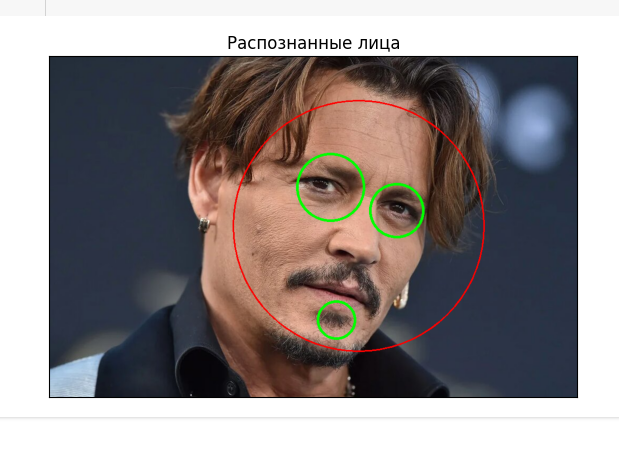

In [ ]:
# Вот так было до исправления
# выполнение распознавания глаз
    # eyes = classifier_eye.detectMultiScale(face)

In [ ]:
# После
    # выполнение распознавания глаз с измененными параметрами так как он думает что оласть под губой это глаз...
    # eyes = classifier_eye.detectMultiScale(face, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))


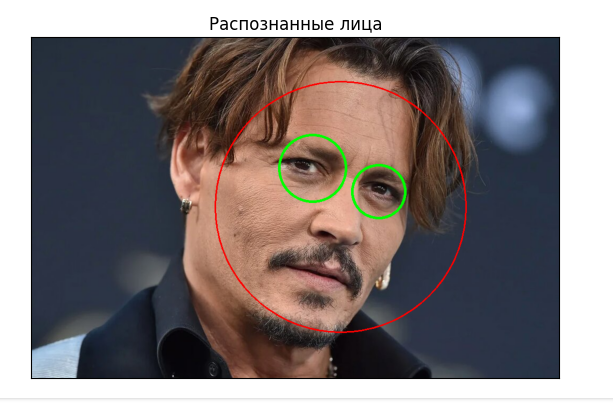

Решил поэкспериментитровать

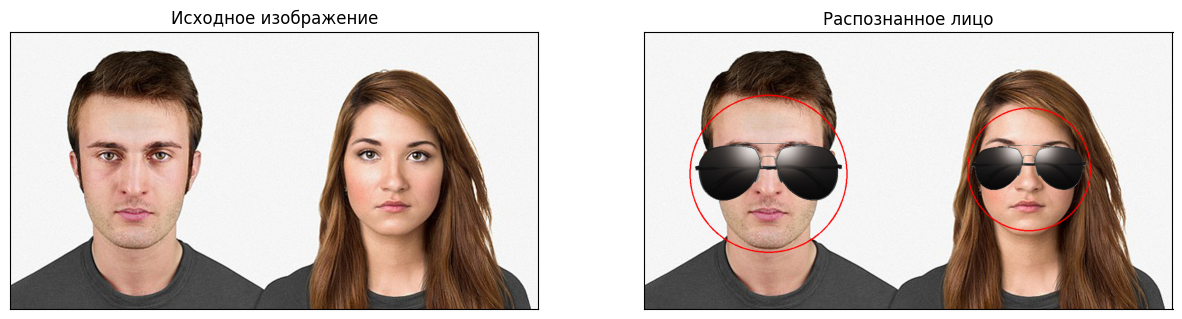

In [ ]:
# Загрузка изображения
img = cv2.imread('/og_og_145772360624878427.jpg')

img2 = img.copy() # копирование переменной

# загрузка каскада Хаара
classifier = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_frontalface_default.xml")

# загрузка каскада Хаара для поиска глаз
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_eye.xml")

# выполнение распознавания лиц
bboxes = classifier.detectMultiScale(img)

# загрузка изображения очков
glasses = cv2.imread('/Black-Glasses-PNG-Transparent-Image.png', -1)  # -1 для загрузки с альфа-каналом

# формирование овала вокруг каждого обнаруженного лица
for box in bboxes:
    # формирование координат
    x, y, width, height = box
    # вычисление центра и радиусов для овала
    center = (x + width // 2, y + height // 2)
    axes = (width // 2, height // 2)  # радиусы по осям
    # рисование овала
    cv2.ellipse(img2, center, axes, 0, 0, 360, (0, 0, 255), 2)

    face = img2[y:y + height, x:x + width]  # найденная область с лицом

    # выполнение распознавания глаз с измененными параметрами так как он думает что область под губой это глаз...
    eyes = classifier_eye.detectMultiScale(face, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # вставка очков на лицо
    if len(eyes) > 0:  # если найдены глаза
        # вычисление позиции для наложения очков
        glasses_width = width
        glasses_height = int(glasses.shape[0] * (glasses_width / glasses.shape[1]))
        glasses_resized = cv2.resize(glasses, (glasses_width, glasses_height))

        # определение позиции для наложения
        y_offset = y + int(height / 4)  # немного выше центра лица
        x_offset = x  # по ширине лица

      # наложение очков на изображение
        for c in range(0, 3):
          img2[y_offset:y_offset + glasses_resized.shape[0], x_offset:x_offset + glasses_resized.shape[1], c] = \
              glasses_resized[:, :, c] * (glasses_resized[:, :, 3] / 255.0) + \
                  img2[y_offset:y_offset + glasses_resized.shape[0], x_offset:x_offset + glasses_resized.shape[1], c] * (1.0 - glasses_resized[:, :, 3] / 255.0)


fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Распознанное лицо')

pyplot.show()

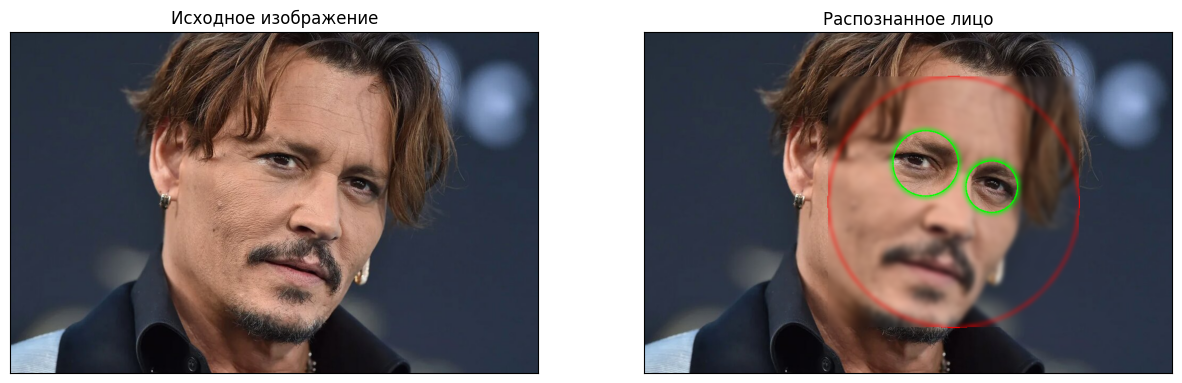

In [ ]:

# Загрузка изображения
img = cv2.imread('/m1000x1000.jpg')

img2 = img.copy() # копирование переменной

# загрузка каскада Хаара
classifier = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_frontalface_default.xml")

# загрузка каскада Хаара для поиска глаз
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_eye.xml")

# выполнение распознавания лиц
bboxes = classifier.detectMultiScale(img)

# формирование овала вокруг каждого обнаруженного лица
# ... существующий код ...

# формирование овала вокруг каждого обнаруженного лица
for box in bboxes:
    # формирование координат
    x, y, width, height = box
    # вычисление центра и радиусов для овала
    center = (x + width // 2, y + height // 2)
    axes = (width // 2, height // 2)  # радиусы по осям
    # рисование овала
    cv2.ellipse(img2, center, axes, 0, 0, 360, (0, 0, 255), 2)

    face = img2[y:y + height, x:x + width]  # найденная область с лицом

    # создание маски для размытия
    mask = np.zeros_like(face)

    # выполнение распознавания глаз с измененными параметрами так как он думает что область под губой это глаз...
    eyes = classifier_eye.detectMultiScale(face, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    for (x_eye, y_eye, w_eye, h_eye) in eyes:
        # определяем центр круга
        center = (int(x_eye + 0.5 * w_eye), int(y_eye + 0.5 * h_eye))
        # вычисляем радиус окружности (подобран эмпирическим путем)
        radius = int(0.3 * (w_eye + h_eye))
        color = (0, 255, 0)  # цвет в RGB
        thickness = 3  # толщина линии
        # рисуем круг
        cv2.circle(face, center, radius, color, thickness)

        # добавляем область глаз в маску
        cv2.circle(mask, center, radius, (255, 255, 255), -1)

    # размываем лицо
    blurred_face = cv2.GaussianBlur(face, (25, 25), 0)

    # комбинируем размытое лицо и оригинал по маске
    face = np.where(mask == np.array([255, 255, 255]), face, blurred_face)

    img2[y:y + height, x:x + width] = face  # обновляем изображение с лицом

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Распознанное лицо')

pyplot.show()